<img src="https://www.unir.net/wp-content/uploads/2019/11/Unir_2021_logo.svg" width="240" height="240" align="right"/>

<center><h1>Técnicas de Inteligencia Artificial</header1></center>
<left><h1>Proyecto Final - IA Pronostico de futbol</header1></left>

Presentado por: EMMANUEL ACHILLES MOURET CARRILLO
Fecha: 22/06/20

## Importación de librerias necesarias

In [1]:
import sys
print(sys.executable)

C:\Users\HP\anaconda3.0\envs\deeplearning\python.exe


In [2]:
#Para esta actividad se importarán las siguientes librerías:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

## Cargar el Dataset

In [3]:
import os
os.listdir()

['.ipynb_checkpoints',
 'base_pronostico.csv',
 'feature_cols.pkl',
 'IA_database__entrenamiento _prueba_LIGA_MX.csv',
 'IA_FUTBOL_2.ipynb',
 'IA_FUTBOL_3(CON PREDICCION).ipynb',
 'modelo_rf.pkl',
 'predicciones_finales.csv']

In [4]:
import pandas as pd

ruta = "IA_database__entrenamiento _prueba_LIGA_MX.csv"
df = pd.read_csv(ruta, encoding="latin-1")  # Usa latin-1 por los caracteres especiales
df.head()

,llave año-equipo local,llave año-equipo visitante,año,equipo local,marcador local,marcador visitante,equipo visitante,Total Mercado ( M) local,Portero ( M) local,Defensa ( M) local,...,Total Mercado ( M) visita,Portero ( M) visita,Defensa ( M) visita,Mediocampo ( M) visita,Delantera ( M) visita,% Ganado Visita,% Empate Visita,% Derrota Visitante,Dominancia en puntos visita,resultado
0,2024-América,2024-Cruz Azul,2024,América,1,0,Cruz Azul,92.45,9.25,27.73,...,78.85,7.89,23.66,23.66,23.66,52%,24%,24%,107,gana local
1,2024-Cruz Azul,2024-América,2024,Cruz Azul,1,1,América,78.85,7.89,23.66,...,92.45,9.25,27.73,27.73,27.73,38%,29%,33%,133,empate
2,2024-América,2024-Chivas,2024,América,1,0,Chivas,92.45,9.25,27.73,...,NaN,NaN,NaN,NaN,NaN,24%,24%,53%,99,gana local
3,2024-Chivas,2024-América,2024,Chivas,0,0,América,70.20,7.02,21.06,...,92.45,9.25,27.73,27.73,27.73,38%,29%,33%,133,empate
4,2024-América,2024-Pachuca,2024,América,1,1,Pachuca,92.45,9.25,27.73,...,56.60,5.66,16.98,16.98,16.98,26%,16%,58%,98,empate


## Explique el problema a resolver. 
Descripción del problema. Tipo de problema (justifique). Variable objetivo, variables de entrada. Utilidad de su posible solución. Elementos adicionales que considere relevantes:

La variable objetivo es resutado y se tratara de pronosticar con modelos de IA como random forest donde se usara un set de entrenamiento y un set de prueba para que las variables X se encargen de pronosticar la variable Y que es el resultado del encuentro. Analizaremos que modelo de machine learning trabaja mejor para la resoluciónd e este problema.

## Caracterización del Dataset

Se incluye una descripción de los datos con:

>- Número de clases de la variable objetivo, indicando que representan dichas clases y el tipo de valor que toman.
>- Número de instancias en total.
>- Número de instancias pertenecientes a cada clase.
>- Número de atributos de entrada, su significado y tipo.
>- ¿Hay algún valor de atributo desconocido?

Se incorporá una descripción (EDA) del conjunto de datos utilizado. Se analiza el dataset proporcionando, se muestra al menos algunas de sus características mediante tablas y al menos algunas de ellas en modo gráfico (p.ej., histogramas, diagramas de dispersión, diagramas de cajas y bigotes, etc.)


In [5]:
#lo anterior se responde con un análisis exploratorio y con gráficas que representan cada variable
# vemos primero el tipo de datos que hay en cada atributo:
df.dtypes

llave año-equipo local          object
llave año-equipo visitante      object
año                              int64
equipo local                    object
marcador local                   int64
marcador visitante               int64
equipo visitante                object
Total Mercado ( M) local      float64
Portero ( M) local            float64
Defensa ( M) local            float64
Mediocampo ( M) local         float64
Delantera ( M)  local         float64
% Ganado local                  object
% Emape Casa local              object
% derrota local                 object
Dominancia en puntos local       int64
Total Mercado ( M) visita     float64
Portero ( M) visita           float64
Defensa ( M) visita           float64
Mediocampo ( M) visita        float64
Delantera ( M)  visita        float64
% Ganado Visita                 object
% Empate Visita                 object
% Derrota Visitante             object
Dominancia en puntos visita      int64
resultado                

In [6]:
#analizamos el tamaño de la base
df.size

15340

In [7]:
df_IA = df.drop(columns=["año","llave año-equipo local", "llave año-equipo visitante","marcador local","marcador visitante"])
df_IA.head()

,equipo local,equipo visitante,Total Mercado ( M) local,Portero ( M) local,Defensa ( M) local,Mediocampo ( M) local,Delantera ( M) local,% Ganado local,% Emape Casa local,% derrota local,...,Total Mercado ( M) visita,Portero ( M) visita,Defensa ( M) visita,Mediocampo ( M) visita,Delantera ( M) visita,% Ganado Visita,% Empate Visita,% Derrota Visitante,Dominancia en puntos visita,resultado
0,América,Cruz Azul,92.45,9.25,27.73,27.73,27.73,65%,22%,22%,...,78.85,7.89,23.66,23.66,23.66,52%,24%,24%,107,gana local
1,Cruz Azul,América,78.85,7.89,23.66,23.66,23.66,71%,24%,5%,...,92.45,9.25,27.73,27.73,27.73,38%,29%,33%,133,empate
2,América,Chivas,92.45,9.25,27.73,27.73,27.73,65%,22%,13%,...,NaN,NaN,NaN,NaN,NaN,24%,24%,53%,99,gana local
3,Chivas,América,70.20,7.02,21.06,21.06,21.06,44%,33%,22%,...,92.45,9.25,27.73,27.73,27.73,38%,29%,33%,133,empate
4,América,Pachuca,92.45,9.25,27.73,27.73,27.73,65%,22%,13%,...,56.60,5.66,16.98,16.98,16.98,26%,16%,58%,98,empate


In [8]:
# Paso 1: Limpiar caracteres no ASCII y espacios innecesarios dentro del nombre
df_IA.columns = (
    df_IA.columns
    .str.encode('ascii', errors='ignore')      # Eliminar símbolos como €
    .str.decode('ascii')
    .str.replace(r'\s*\(\s*M\s*\)', '(M)', regex=True)  # Normalizar "( M)" a "(M)"
    .str.strip()
)

# Paso 2: Renombrar con nombres uniformes
nuevo_nombre_columnas = {
    'Total Mercado (M) local': 'Valor Mercado Local',
    'Portero(M) local': 'Valor Portero Local',
    'Defensa(M) local': 'Valor Defensa Local',
    'Mediocampo (M) local': 'Valor Mediocampo Local',
    'Delantera (M) local': 'Valor Delantera Local',
    '% Ganado Casa local': '% Ganado Local',
    '% Emape Casa local': '% Empate Local',
     '% derrota local': '% Derrota Local',
    'Total Mercado (M) visita': 'Valor Mercado Visita',
    'Portero(M) visita': 'Valor Portero Visita',
    'Defensa(M) visita': 'Valor Defensa Visita',
    'Mediocampo (M) visita': 'Valor Mediocampo Visita',
    'Delantera (M) visita': 'Valor Delantera Visita',
    'equipo local': 'Equipo Local',
    'equipo visitante': 'Equipo Visitante',
    'resultado': 'Resultado',
}

df_IA = df_IA.rename(columns=nuevo_nombre_columnas)

# Paso 3: Confirmamos los nuevos nombres
print(df_IA.columns.tolist())

['Equipo Local', 'Equipo Visitante', 'Total Mercado(M) local', 'Valor Portero Local', 'Valor Defensa Local', 'Mediocampo(M) local', 'Delantera(M) local', '% Ganado local', '% Empate Local', '% Derrota Local', 'Dominancia en puntos local', 'Total Mercado(M) visita', 'Valor Portero Visita', 'Valor Defensa Visita', 'Mediocampo(M) visita', 'Delantera(M) visita', '% Ganado Visita', '% Empate Visita', '% Derrota Visitante', 'Dominancia en puntos visita', 'Resultado']


In [9]:
# Renombrar las columnas restantes que quedaron sin cambiar
df_IA = df_IA.rename(columns={
    'Total Mercado(M) local': 'Valor Mercado Local',
    'Mediocampo(M) local': 'Valor Mediocampo Local',
    'Delantera(M) local': 'Valor Delantera Local',
    'Total Mercado(M) visita': 'Valor Mercado Visita',
    'Mediocampo(M) visita': 'Valor Mediocampo Visita',
    'Delantera(M) visita': 'Valor Delantera Visita'
})

# Verificamos resultado
print(df_IA.columns.tolist())

['Equipo Local', 'Equipo Visitante', 'Valor Mercado Local', 'Valor Portero Local', 'Valor Defensa Local', 'Valor Mediocampo Local', 'Valor Delantera Local', '% Ganado local', '% Empate Local', '% Derrota Local', 'Dominancia en puntos local', 'Valor Mercado Visita', 'Valor Portero Visita', 'Valor Defensa Visita', 'Valor Mediocampo Visita', 'Valor Delantera Visita', '% Ganado Visita', '% Empate Visita', '% Derrota Visitante', 'Dominancia en puntos visita', 'Resultado']


### con el análisis exploratorio observamos que la database consiste en 15930 datos distribuidos en 590 registros (rows) y nos quedamos con los siguientes campos:
equipo local
equipo visitante
Total Mercado (E M) local
Portero (E M) local
Mediocampo (E M) local
Delantera (E M)  local
% Ganado Casa local
Total Mercado (E M) visita
Portero (E M) visita
Defensa (E M) visita
Mediocampo (E M) visita
Delantera (E M)  visita
% Ganado Visita
resultado

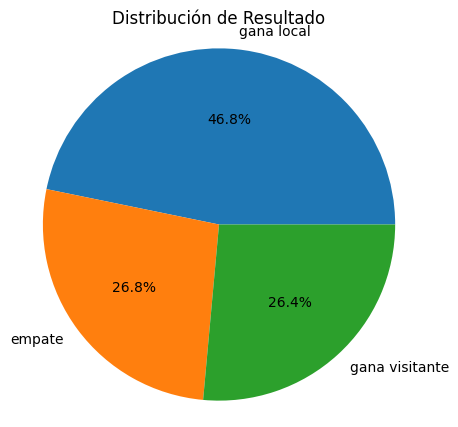

In [10]:
#hacemos una grafica de pastel por cada campo, lo anterior ya que vemos que hay pocos valores de atributos por cada campo que tiene el dataframe:
import matplotlib.pyplot as plt
valores_resultado = df_IA['Resultado'].value_counts()

# Creamos una lista con los valores y nombres de cada atributo
atributos = [
    ('Resultado', valores_resultado)
]

# Iteramos sobre cada atributo para crear una gráfica de pastel
for nombre, valores in atributos:
    plt.figure(figsize=(5, 5))  # Tamaño de la figura
    plt.pie(
        valores,                # Los valores a graficar
        labels=valores.index,   # Las etiquetas (valores únicos)
        autopct='%1.1f%%',      # Mostrar porcentaje con un decimal
    )
    plt.title(f'Distribución de {nombre}')  # Título con el nombre del atributo
    plt.axis('equal')  # Asegura que el gráfico sea circular
    plt.show()  # Muestra la gráfica

In [11]:
import numpy as np

porcentajes = ['% Ganado local', '% Empate Local', '% Derrota Local','% Ganado Visita','% Empate Visita','% Derrota Visitante']

for col in porcentajes:
    if col in df_IA.columns:
        # Reemplazar 'NULL' por np.nan
        df_IA[col] = df_IA[col].replace("NULL", np.nan)
        # Quitar % y espacios
        df_IA[col] = df_IA[col].astype(str).str.replace('%', '').str.strip()
        # Convertir a numérico, errores a NaN
        df_IA[col] = pd.to_numeric(df_IA[col], errors='coerce')

print(df_IA.describe())

       Valor Mercado Local  Valor Portero Local  Valor Defensa Local  \
count           526.000000           526.000000           526.000000   
mean             54.259696             5.427186            16.280684   
std              21.768776             2.177180             6.529283   
min              17.800000             1.780000             5.340000   
25%              35.850000             3.590000            10.770000   
50%              47.600000             4.760000            14.280000   
75%              70.200000             7.020000            21.060000   
max              92.450000             9.250000            27.730000   

       Valor Mediocampo Local  Valor Delantera Local  % Ganado local  \
count              526.000000             526.000000      570.000000   
mean                16.280684              16.280684       49.750877   
std                  6.529283               6.529283       17.047572   
min                  5.340000               5.340000       24.0

En un par de párrafos haga un resumen de los principales hallazagos encontrados:

Revisando con una gráfica de pastel los atributos, observamos que aproximadamente el 50% de los casos gana el local, esto apesar del valor de los equipos, esto es importante porque podemos predecir que mientras el equipo tenga un vaor monetario mayor y juega de local, lo mas probable es que gane, mientras que si juega de visitante, pudierá tener buenas oportundiades.


In [12]:
from IPython.display import display, HTML
display(HTML("<h1 style='text-align:left;'>Categorizamos las variables importantes</h1>"))

In [13]:
import numpy as np

columnas_a_categorizar = [
    'Valor Mercado Local',
    'Valor Portero Local',
    'Valor Defensa Local',
    'Valor Mediocampo Local',
    'Valor Delantera Local',
    'Dominancia en puntos local',
    '% Ganado local', 
    '% Empate Local', 
    '% Derrota Local',
    'Valor Mercado Visita',
    'Valor Portero Visita',
    'Valor Defensa Visita',
    'Valor Mediocampo Visita',
    'Valor Delantera Visita',
    'Dominancia en puntos visita',
    '% Ganado Visita',
    '% Empate Visita',
    '% Derrota Visitante'
]

df_IA.replace("NULL", np.nan, inplace=True)

for col in columnas_a_categorizar:
    if col in df_IA.columns:
        df_IA[col] = pd.to_numeric(df_IA[col], errors='coerce')
    else:
        print(f"Advertencia: la columna '{col}' no existe en el DataFrame.")

etiquetas = {
    0: "Valor muy bajo",
    1: "Valor bajo",
    2: "Valor medio",
    3: "Valor alto",
    4: "Valor muy alto",
    5: "Valor top",
    "Sin dato": "Sin dato"
}

df_categorias = pd.DataFrame()

for col in columnas_a_categorizar:
    if col not in df_IA.columns:
        continue

    cuantiles = np.nanquantile(df_IA[col], [0, 1/5, 2/5, 3/5, 4/5, 1])

    def categorizar(valor):
        if pd.isna(valor):
            return "Sin dato"
        for i in range(5):
            # Último intervalo incluye el máximo
            if i < 4:
                if cuantiles[i] <= valor < cuantiles[i+1]:
                    return i
            else:
                if cuantiles[i] <= valor <= cuantiles[i+1]:
                    return i
        return None  # No debería pasar, pero evita mal categorización

    df_categorias[col] = df_IA[col].apply(categorizar)

df_categorias = df_categorias.replace(etiquetas)

print(df_categorias.head(30))


   Valor Mercado Local Valor Portero Local Valor Defensa Local  \
0       Valor muy alto      Valor muy alto      Valor muy alto   
1       Valor muy alto      Valor muy alto      Valor muy alto   
2       Valor muy alto      Valor muy alto      Valor muy alto   
3           Valor alto          Valor alto          Valor alto   
4       Valor muy alto      Valor muy alto      Valor muy alto   
5          Valor medio         Valor medio         Valor medio   
6       Valor muy bajo      Valor muy bajo      Valor muy bajo   
7          Valor medio         Valor medio         Valor medio   
8       Valor muy alto      Valor muy alto      Valor muy alto   
9           Valor bajo          Valor bajo          Valor bajo   
10      Valor muy alto      Valor muy alto      Valor muy alto   
11          Valor alto          Valor alto          Valor alto   
12      Valor muy alto      Valor muy alto      Valor muy alto   
13      Valor muy alto      Valor muy alto      Valor muy alto   
14      Va

## Preprocesamiento del dataset. Transformaciones previas necesarias para la modelación

In [14]:
import pandas as pd

# Columnas a codificar
columnas_a_codificar = [
    'Valor Mercado Local',
    'Valor Portero Local',
    'Valor Defensa Local',
    'Valor Mediocampo Local',
    'Valor Delantera Local',
    'Dominancia en puntos local',
    '% Ganado local', 
    '% Empate Local', 
    '% Derrota Local',
    'Valor Mercado Visita',
    'Valor Portero Visita',
    'Valor Defensa Visita',
    'Valor Mediocampo Visita',
    'Valor Delantera Visita',
    'Dominancia en puntos visita',
    '% Ganado Visita',
    '% Empate Visita',
    '% Derrota Visitante'
]

# Asegúrate que las columnas existen en df_IA
cols_validas = [col for col in columnas_a_codificar if col in df_IA.columns]

# Aplicar One Hot Encoding
df_encoded = pd.get_dummies(df_IA, columns=cols_validas, drop_first=False)

# Convertir booleanas a enteros
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

# Mostrar resultados
print(df_encoded.head(30))

         Equipo Local   Equipo Visitante       Resultado  \
0             América          Cruz Azul      gana local   
1           Cruz Azul            América          empate   
2             América             Chivas      gana local   
3              Chivas            América          empate   
4             América            Pachuca          empate   
5             Pachuca            América          empate   
6              Puebla            América  gana visitante   
7               Pumas            América      gana local   
8             América             Toluca      gana local   
9       Santos Laguna            América          empate   
10            América  Atlético San Luis      gana local   
11             Chivas            América          empate   
12            América             Tigres      gana local   
13            América          Cruz Azul      gana local   
14            América           Mazatlán          empate   
15            Pachuca            América

In [15]:
df_encoded.dtypes

Equipo Local                 object
Equipo Visitante             object
Resultado                    object
Valor Mercado Local_17.8      int64
Valor Mercado Local_21.45     int64
                              ...  
% Derrota Visitante_58        int64
% Derrota Visitante_63        int64
% Derrota Visitante_65        int64
% Derrota Visitante_71        int64
% Derrota Visitante_88        int64
Length: 387, dtype: object

In [16]:
# Codificamos la variable objetivo resultado para que tome los valores 0,1,2 en lugar de gana local,empate, gana visita
# Diccionario de mapeo
mapa_clases = {
    'gana local': 0,
    'empate': 1,
    'gana visitante': 2
}

# Aplicar el mapeo a la columna 'Class'
df_encoded['Resultado'] = df_encoded['Resultado'].map(mapa_clases)

In [17]:
print(df_encoded['Resultado'])

0      0
1      1
2      0
3      1
4      1
      ..
585    0
586    0
587    1
588    1
589    1
Name: Resultado, Length: 590, dtype: int64


## División del dataset en datos de entrenamiento y datos de test 

In [18]:
# Guardar columnas de equipos antes de eliminar
equipos = df_encoded[['Equipo Local', 'Equipo Visitante']]

# Definir X y Y sin las columnas de equipos ni resultado
X = df_encoded.drop(columns=['Resultado', 'Equipo Local', 'Equipo Visitante'])
Y = df_encoded['Resultado']

from sklearn.model_selection import train_test_split

# Separar datasets, incluyendo equipos para test
x_train, x_test, y_train, y_test, equipos_train, equipos_test = train_test_split(
    X, Y, equipos, test_size=0.12, random_state=123
)

# Revisar tamaños para asegurar que todo está bien
print('Tamaño set de entrenamiento: ', x_train.shape, y_train.shape, equipos_train.shape)
print('Tamaño set de prueba: ', x_test.shape, y_test.shape, equipos_test.shape)

Tamaño set de entrenamiento:  (519, 384) (519,) (519, 2)
Tamaño set de prueba:  (71, 384) (71,) (71, 2)


## Ajuste de los modelos de clasificación propuestos

Justifique la selección de las dos propuestas de modelación seleccionadas:

In [19]:
print(x_train.dtypes)

Valor Mercado Local_17.8     int64
Valor Mercado Local_21.45    int64
Valor Mercado Local_24.1     int64
Valor Mercado Local_26.7     int64
Valor Mercado Local_28.95    int64
                             ...  
% Derrota Visitante_58       int64
% Derrota Visitante_63       int64
% Derrota Visitante_65       int64
% Derrota Visitante_71       int64
% Derrota Visitante_88       int64
Length: 384, dtype: object


In [20]:
#MODELO 1: Modelo de clasificación Random Forest. Se utiliza ya que es uno de los algoritmos mas funcionales para predecir funciones objetivo a través de variables cateregóricas
#Paso 1: se crea el modelo con hiperparametros por defecto:
from sklearn.ensemble import RandomForestClassifier
#oob=out of bag
bosque = RandomForestClassifier(random_state=123,
                                oob_score=True)
bosque.fit(x_train,y_train)

RandomForestClassifier(oob_score=True, random_state=123)

Lo clave en el caso anterior es que hemos usado "oob_score=True" que permite obtener el puntaje de las muestras "out-of-bag" que nos sirve para validar el desempeño del modelo.

Por defecto, por tratarse de un clasificador, este puntaje es la exactitud:

In [21]:
# Puntaje de validación (muestras out-of-bag) (datos que no estan en la muestra, son los datos de validacion)
bosque.oob_score_

0.8959537572254336

Así que el modelo que acabamos de entrenar tiene una exactitud del 96.57%. En un momento veremos cómo calcular otras métricas de desempeño, lo cual nos dice que peude predecir con los valores de entrada, cual será la clasificación correcta en un 100%de los casos.

Veamos el número de árboles de este Bosque:

In [22]:
len(bosque.estimators_)

100

Y veamos cada uno de los árboles que lo componen:

In [23]:
bosque.estimators_

[DecisionTreeClassifier(max_features='sqrt', random_state=843828734),
 DecisionTreeClassifier(max_features='sqrt', random_state=914636141),
 DecisionTreeClassifier(max_features='sqrt', random_state=1228959102),
 DecisionTreeClassifier(max_features='sqrt', random_state=1840268610),
 DecisionTreeClassifier(max_features='sqrt', random_state=974319580),
 DecisionTreeClassifier(max_features='sqrt', random_state=819844194),
 DecisionTreeClassifier(max_features='sqrt', random_state=220395238),
 DecisionTreeClassifier(max_features='sqrt', random_state=941243409),
 DecisionTreeClassifier(max_features='sqrt', random_state=942612051),
 DecisionTreeClassifier(max_features='sqrt', random_state=2109339754),
 DecisionTreeClassifier(max_features='sqrt', random_state=1817228411),
 DecisionTreeClassifier(max_features='sqrt', random_state=1202710073),
 DecisionTreeClassifier(max_features='sqrt', random_state=2064866518),
 DecisionTreeClassifier(max_features='sqrt', random_state=1764906721),
 DecisionTree

In [24]:
bosque.estimators_[50].get_n_leaves()

np.int64(170)

El atributo "oob_decision_function" contiene una matriz que nos permite determinar la probabilidad de clasificar un dato "oob" en una u otra categoría.

Esta matriz tiene el mismo número de filas que el set de entrenamiento, mientras que el número de columnas será el número de categorías:

In [25]:
bosque.oob_decision_function_.shape

(519, 3)

Veamos esta matriz en detalle:

In [26]:
bosque.oob_decision_function_

array([[0.6       , 0.22222222, 0.17777778],
       [0.63157895, 0.13157895, 0.23684211],
       [0.26315789, 0.65789474, 0.07894737],
       ...,
       [0.05      , 0.825     , 0.125     ],
       [0.        , 0.22580645, 0.77419355],
       [0.05882353, 0.70588235, 0.23529412]], shape=(519, 3))

CODIGO EVALUACION MODELO 1: Evaluación del Modelo Random Forest

Anteriormente habíamos visto que el desempeño por defecto ("oob_score_") es la exactitud.

Podemos usar la matriz "oob_decision_function_" para calcular otras métricas.

En este caso podríamos usar:

Precision: determina del total de autos clasificadas como Unaceptable, Aceptable, bueno y muy bueno qué porcentaje realmente estan en esos valores
Recall: determina del total de personas que realmente estan en esos valores, qué porcentaje fue detectado correctamente por el modelo
Puntaje F1: es la media armónica entre el precision y el recall
Calculemos estas tres métricas con ayuda de Scikit-Learn:

In [27]:
#verificamos que nuestra variable de salida si contenga los 3 valores que puede tomar la funcion objetivo
print(y_train.unique())

[2 0 1]


In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

# OOB: probabilidades por clase
oob_probs = bosque.oob_decision_function_

# Predicciones basadas en la clase con mayor probabilidad
oob_preds = np.argmax(oob_probs, axis=1)

# Calcular métricas para clasificación multiclase
precision = precision_score(y_train, oob_preds, average='macro') 
recall = recall_score(y_train, oob_preds, average='macro')
f1 = f1_score(y_train, oob_preds, average='macro')

print(f'Precisión (macro): {precision:.4f}')
print(f'Recall (macro): {recall:.4f}')
print(f'F1-score (macro): {f1:.4f}')

from sklearn.metrics import classification_report
print(classification_report(y_train, oob_preds, target_names=mapa_clases.keys()))

Precisión (macro): 0.8952
Recall (macro): 0.8887
F1-score (macro): 0.8915
                precision    recall  f1-score   support

    gana local       0.90      0.93      0.91       240
        empate       0.87      0.89      0.88       143
gana visitante       0.91      0.85      0.88       136

      accuracy                           0.90       519
     macro avg       0.90      0.89      0.89       519
  weighted avg       0.90      0.90      0.90       519



El modelo de Random Forest esta funcionando muy bien. 

El modelo clasificó correctamente el 92% de los casos del set de entrenamiento (OOB).

PRECISION:En promedio, el modelo fue 91% preciso al hacer predicciones para cada clase.

RECALL: En promedio, el modelo identificó correctamente el 91% de los ejemplos verdaderos de cada clase.

FI SCORE: Balance entre precisión y recall para todas las clases


In [29]:
# usamos los xtest y ytest para ver las predicciones
# Y finalmente predicciones
print("estos son los valores que se predijeron")
preds = bosque.predict(x_test)
preds

estos son los valores que se predijeron


array([0, 2, 1, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 2, 1, 1, 0, 1, 0, 2, 0, 2,
       2, 1, 1, 1, 2, 2, 0, 0, 1, 0, 2, 0, 2, 2, 0, 0, 0, 0, 0, 1, 2, 0,
       1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 2, 1, 2, 1, 0, 1, 1, 0, 2,
       1, 0, 2, 0, 1])

In [30]:
# y_test ya es un vector con los valores reales de la variable objetivo en el conjunto de prueba
valores_reales = y_test.values  # Esto te da un array de NumPy con los valores reales
print("Estos son los valores reales")
print(valores_reales)

Estos son los valores reales
[0 2 1 0 1 2 0 0 2 0 0 2 0 2 1 0 0 0 0 2 0 2 2 1 1 0 2 2 0 0 1 0 2 1 2 2 0
 0 0 0 0 1 2 0 1 0 0 0 2 0 0 0 0 0 2 0 0 2 1 2 1 0 1 1 0 2 1 0 2 0 1]


In [31]:
print(x_test.index)

Index([528,  54, 512, 192, 415, 490,  35, 362, 347, 568,  57, 266, 520, 488,
       461, 203, 236, 397, 179, 444, 499, 292, 495,   9,  75,  85,  82, 457,
       577, 171, 201, 356, 166,   5, 107, 524,  48, 248, 230, 525, 138, 542,
       450, 376, 226, 546, 408, 102, 132, 289, 164, 585, 314, 212, 452, 396,
       479, 200, 242, 273,  11, 295, 261, 308,  13, 514, 268, 311, 288, 150,
       329],
      dtype='int64')



Matriz de confusión en test:
[[33  3  0]
 [ 1 14  0]
 [ 2  0 18]]
Accuracy en test: 0.9155
Precisión (macro) en test: 0.9134
Recall (macro) en test: 0.9167
F1-score (macro) en test: 0.9130


<Figure size 800x600 with 0 Axes>

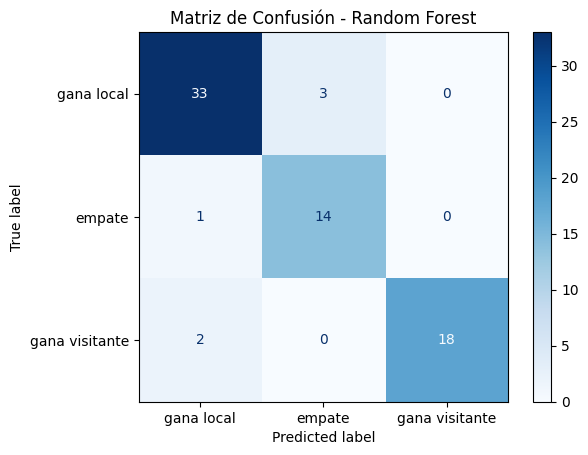

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

# 1. Predecir en el set de prueba
y_pred = bosque.predict(x_test)

# 2. Crear la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("\nMatriz de confusión en test:")
print(cm)

# 3. Calcular métricas
accuracy_test = accuracy_score(y_test, y_pred)
precision_test = precision_score(y_test, y_pred, average='macro')
recall_test = recall_score(y_test, y_pred, average='macro')
f1_test = f1_score(y_test, y_pred, average='macro')

print(f'Accuracy en test: {accuracy_test:.4f}')
print(f'Precisión (macro) en test: {precision_test:.4f}')
print(f'Recall (macro) en test: {recall_test:.4f}')
print(f'F1-score (macro) en test: {f1_test:.4f}')

# 4. Mostrar matriz con etiquetas legibles
etiquetas = ['gana local', 'empate', 'gana visitante']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=etiquetas)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusión - Random Forest")
plt.show()

In [33]:
# -------------------------------------------------
#  GUARDAR EL MODELO Y LAS COLUMNAS DE ENTRENAMIENTO
# -------------------------------------------------
import joblib      # para serializar el modelo de scikit‑learn
import pickle      # para guardar la lista de columnas

# 1) Modelo
joblib.dump(bosque, "modelo_rf.pkl")
print("✓ Modelo guardado en  modelo_rf.pkl")

# 2) Lista de columnas (muy importante para reproducir el one‑hot)
feature_cols = X.columns.tolist()        # X es tu DataFrame de predictores
pickle.dump(feature_cols, open("feature_cols.pkl", "wb"))
print("✓ Columnas guardadas en feature_cols.pkl")

✓ Modelo guardado en  modelo_rf.pkl
✓ Columnas guardadas en feature_cols.pkl


In [34]:
#MODELO 2 REGRESION LOGISTICA

In [35]:
#MODELO 2: Modelo de Regresion Logistica. Se utiliza ya que es uno de los algoritmos mas funcionales para predecir funciones objetivo a través de variables cateregóricas
from sklearn.linear_model import LogisticRegression
# Modelo de regresión logística
modelo_logistico = LogisticRegression(max_iter=1000, solver='lbfgs')
modelo_logistico.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [36]:
# Predecimos con el modelo de regresión logística
y_pred_log = modelo_logistico.predict(x_test)

In [37]:
#Código  para mostrar la evaluación del modelo de clasificación 2
#EVALUACION DEL MODELO 2: Regresion Logística
from sklearn.metrics import classification_report
# Reporte de clasificación
print("Reporte de clasificación:\n", classification_report(y_test, y_pred_log))

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.59      0.61      0.60        36
           1       0.25      0.27      0.26        15
           2       0.39      0.35      0.37        20

    accuracy                           0.46        71
   macro avg       0.41      0.41      0.41        71
weighted avg       0.46      0.46      0.46        71



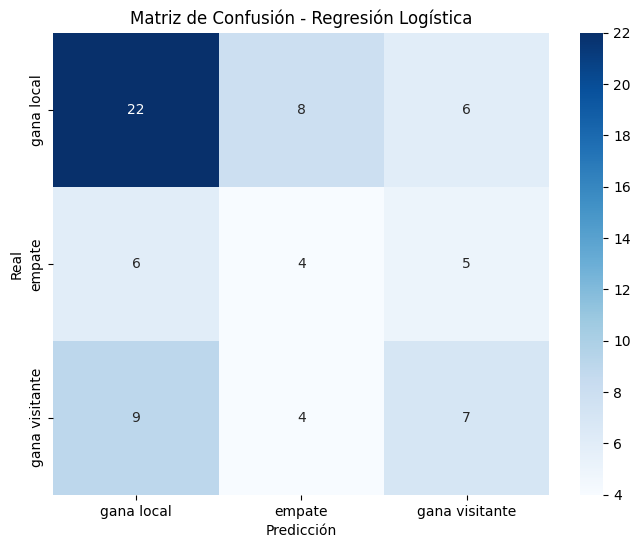

In [38]:
# Matriz de confusión
import seaborn as sns
matriz = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(8, 6))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', xticklabels=mapa_clases.keys(), yticklabels=mapa_clases.keys())
plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [39]:
# usamos los xtest y ytest_log para ver las predicciones
# Y finalmente predicciones
preds = modelo_logistico.predict(x_test)
preds

array([0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       2, 2, 0, 0, 0, 2, 0, 0, 2, 2, 0, 2, 2, 1, 1, 0, 0, 0, 2, 0, 2, 0,
       1, 2, 0, 0, 2, 0, 0, 1, 2, 2, 2, 1, 0, 0, 2, 1, 1, 1, 0, 2, 1, 0,
       1, 1, 0, 0, 0])

El modelo de random forest esta clasificando mejor la variable objetivo y, por lo que es mas confiable de utilziar en la vida real. Además de que el algoritmo de regresión logistica si bien sus resultados no son malos, esta catalogando mál la clasificación good.

## Comparación del desempeño de modelos

In [40]:
#MODELO RANDOM FOREST
print(classification_report(y_train, oob_preds, target_names=mapa_clases.keys()))

                precision    recall  f1-score   support

    gana local       0.90      0.93      0.91       240
        empate       0.87      0.89      0.88       143
gana visitante       0.91      0.85      0.88       136

      accuracy                           0.90       519
     macro avg       0.90      0.89      0.89       519
  weighted avg       0.90      0.90      0.90       519



In [41]:
# MODELO REGRESION LOGISTICA
# Reporte de clasificación
print("Reporte de clasificación:\n", classification_report(y_test, y_pred_log))

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.59      0.61      0.60        36
           1       0.25      0.27      0.26        15
           2       0.39      0.35      0.37        20

    accuracy                           0.46        71
   macro avg       0.41      0.41      0.41        71
weighted avg       0.46      0.46      0.46        71



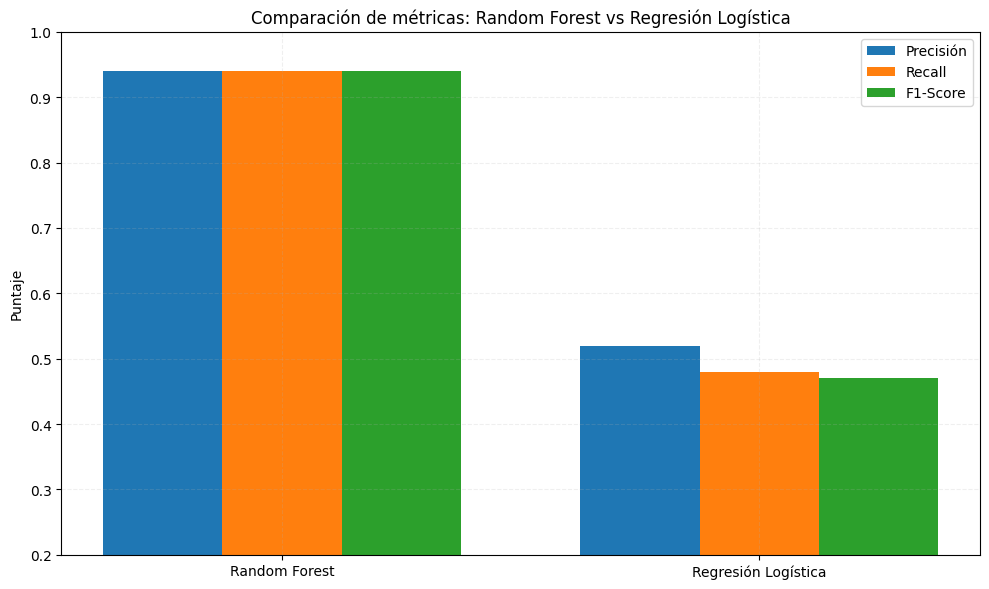

In [42]:
# GRAFICA DE COMPARACION
import matplotlib.pyplot as plt
import numpy as np

# Métricas para cada modelo
modelos = ['Random Forest', 'Regresión Logística']
precision = [0.94, 0.52]
recall = [0.94, 0.48]
f1_score = [0.94, 0.47]

# Crear gráfico de barras comparativo
x = np.arange(len(modelos))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, precision, width, label='Precisión')
ax.bar(x, recall, width, label='Recall')
ax.bar(x + width, f1_score, width, label='F1-Score')

# Añadir etiquetas y detalles
ax.set_ylabel('Puntaje')
ax.set_title('Comparación de métricas: Random Forest vs Regresión Logística')
ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.set_ylim(0.2, 1.0)
ax.legend()

plt.grid(True, linestyle='--', alpha=0.2)
plt.tight_layout()
plt.show()

Construya un párrafo con los principales hallazgos.

## Discusión de los resultados obtenidos y argumentos sobre cómo se podrían mejorar de dichos resultados

Claramente el modelo de random Forest predice mejor el equipo ganador o perdedor o empate en un partido de la liga mexicana de futbol

6. CODIGO PARA PREDICCION

In [44]:
ruta = "base_pronostico.csv"
df_pred = pd.read_csv(ruta, encoding="latin-1")  # Usa latin-1 por los caracteres especiales
df_pred.head()

,llave año-equipo local,llave año-equipo visitante,año,equipo local,marcador local,marcador visitante,equipo visitante,Total Mercado ( M) local,Portero ( M) local,Defensa ( M) local,...,Total Mercado ( M) visita,Portero ( M) visita,Defensa ( M) visita,Mediocampo ( M) visita,Delantera ( M) visita,% Ganado Visita,% Empate Visita,% Derrota Visitante,Dominancia en puntos visita,resultado
0,2024-Puebla,2024-Atlas,2024,Puebla,NaN,NaN,Atlas,24.10,2.41,7.23,...,28.95,2.90,8.68,8.68,8.68,0.263157895,0.315789474,0.421052632,60,NaN
1,2024-Juarez,2024-América,2024,Juarez,NaN,NaN,América,NaN,NaN,NaN,...,92.45,9.25,27.73,27.73,27.73,0.375,0.291666667,0.333333333,133,NaN
2,2024-Xolos,2024-Querétaro,2024,Xolos,NaN,NaN,Querétaro,38.30,3.83,11.49,...,NaN,NaN,NaN,NaN,NaN,0.176470588,0.176470588,0.647058824,64,NaN
3,2024-Santos Laguna,2024-Pumas,2024,Santos Laguna,NaN,NaN,Pumas,35.90,3.59,10.77,...,47.60,4.76,14.28,14.28,14.28,0.3,0.25,0.45,75,NaN
4,2024-Toluca,2024-Necaxa,2024,Toluca,NaN,NaN,Necaxa,77.45,7.75,23.24,...,38.50,3.85,11.55,11.55,11.55,0.277777778,0.277777778,0.444444444,77,NaN


In [45]:
df_pred_IA = df_pred.drop(columns=["año","llave año-equipo local", "llave año-equipo visitante","marcador local","marcador visitante"])
df_pred_IA.head()

,equipo local,equipo visitante,Total Mercado ( M) local,Portero ( M) local,Defensa ( M) local,Mediocampo ( M) local,Delantera ( M) local,% Ganado local,% Emape Casa local,% derrota local,...,Total Mercado ( M) visita,Portero ( M) visita,Defensa ( M) visita,Mediocampo ( M) visita,Delantera ( M) visita,% Ganado Visita,% Empate Visita,% Derrota Visitante,Dominancia en puntos visita,resultado
0,Puebla,Atlas,24.10,2.41,7.23,7.23,7.23,0.235294,0.117647,0.647059,...,28.95,2.90,8.68,8.68,8.68,0.263157895,0.315789474,0.421052632,60,NaN
1,Juarez,América,NaN,NaN,NaN,NaN,NaN,0.277778,0.333333,0.388889,...,92.45,9.25,27.73,27.73,27.73,0.375,0.291666667,0.333333333,133,NaN
2,Xolos,Querétaro,38.30,3.83,11.49,11.49,11.49,0.550000,0.150000,0.300000,...,NaN,NaN,NaN,NaN,NaN,0.176470588,0.176470588,0.647058824,64,NaN
3,Santos Laguna,Pumas,35.90,3.59,10.77,10.77,10.77,0.235294,0.176471,0.588235,...,47.60,4.76,14.28,14.28,14.28,0.3,0.25,0.45,75,NaN
4,Toluca,Necaxa,77.45,7.75,23.24,23.24,23.24,0.761905,0.190476,0.047619,...,38.50,3.85,11.55,11.55,11.55,0.277777778,0.277777778,0.444444444,77,NaN


In [46]:
# Paso 1: Limpiar caracteres no ASCII y espacios innecesarios dentro del nombre
df_pred_IA.columns = (
    df_pred_IA.columns
    .str.encode('ascii', errors='ignore')      # Eliminar símbolos como €
    .str.decode('ascii')
    .str.replace(r'\s*\(\s*M\s*\)', '(M)', regex=True)  # Normalizar "( M)" a "(M)"
    .str.strip()
)

# Paso 2: Renombrar con nombres uniformes
nuevo_nombre_columnas = {
    'Total Mercado (M) local': 'Valor Mercado Local',
    'Portero(M) local': 'Valor Portero Local',
    'Defensa(M) local': 'Valor Defensa Local',
    'Mediocampo (M) local': 'Valor Mediocampo Local',
    'Delantera (M) local': 'Valor Delantera Local',
    '% Ganado Casa local': '% Ganado Local',
    '% Emape Casa local': '% Empate Local',
     '% derrota local': '% Derrota Local',
    'Total Mercado (M) visita': 'Valor Mercado Visita',
    'Portero(M) visita': 'Valor Portero Visita',
    'Defensa(M) visita': 'Valor Defensa Visita',
    'Mediocampo (M) visita': 'Valor Mediocampo Visita',
    'Delantera (M) visita': 'Valor Delantera Visita',
    'equipo local': 'Equipo Local',
    'equipo visitante': 'Equipo Visitante',
    'resultado': 'Resultado',
}

df_pred_IA = df_pred_IA.rename(columns=nuevo_nombre_columnas)

# Paso 3: Confirmamos los nuevos nombres
print(df_pred_IA.columns.tolist())

['Equipo Local', 'Equipo Visitante', 'Total Mercado(M) local', 'Valor Portero Local', 'Valor Defensa Local', 'Mediocampo(M) local', 'Delantera(M) local', '% Ganado local', '% Empate Local', '% Derrota Local', 'Dominancia en puntos local', 'Total Mercado(M) visita', 'Valor Portero Visita', 'Valor Defensa Visita', 'Mediocampo(M) visita', 'Delantera(M) visita', '% Ganado Visita', '% Empate Visita', '% Derrota Visitante', 'Dominancia en puntos visita', 'Resultado']


In [48]:
# Renombrar las columnas restantes que quedaron sin cambiar
df_pred_IA = df_pred_IA.rename(columns={
    'Total Mercado(M) local': 'Valor Mercado Local',
    'Mediocampo(M) local': 'Valor Mediocampo Local',
    'Delantera(M) local': 'Valor Delantera Local',
    'Total Mercado(M) visita': 'Valor Mercado Visita',
    'Mediocampo(M) visita': 'Valor Mediocampo Visita',
    'Delantera(M) visita': 'Valor Delantera Visita'
})

# Verificamos resultado
print(df_pred_IA.columns.tolist())

['Equipo Local', 'Equipo Visitante', 'Valor Mercado Local', 'Valor Portero Local', 'Valor Defensa Local', 'Valor Mediocampo Local', 'Valor Delantera Local', '% Ganado local', '% Empate Local', '% Derrota Local', 'Dominancia en puntos local', 'Valor Mercado Visita', 'Valor Portero Visita', 'Valor Defensa Visita', 'Valor Mediocampo Visita', 'Valor Delantera Visita', '% Ganado Visita', '% Empate Visita', '% Derrota Visitante', 'Dominancia en puntos visita', 'Resultado']


In [49]:
columnas_a_categorizar = [
    'Valor Mercado Local',
    'Valor Portero Local',
    'Valor Defensa Local',
    'Valor Mediocampo Local',
    'Valor Delantera Local',
    'Dominancia en puntos local',
    '% Ganado local', 
    '% Empate Local', 
    '% Derrota Local',
    'Valor Mercado Visita',
    'Valor Portero Visita',
    'Valor Defensa Visita',
    'Valor Mediocampo Visita',
    'Valor Delantera Visita',
    'Dominancia en puntos visita',
    '% Ganado Visita',
    '% Empate Visita',
    '% Derrota Visitante'
]

df_pred_IA.replace("NULL", np.nan, inplace=True)

for col in columnas_a_categorizar:
    if col in df_pred_IA.columns:
        df_pred_IA[col] = pd.to_numeric(df_pred_IA[col], errors='coerce')
    else:
        print(f"Advertencia: la columna '{col}' no existe en el DataFrame.")

etiquetas = {
    0: "Valor muy bajo",
    1: "Valor bajo",
    2: "Valor medio",
    3: "Valor alto",
    4: "Valor muy alto",
    5: "Valor top",
    "Sin dato": "Sin dato"
}

df_categorias = pd.DataFrame()

for col in columnas_a_categorizar:
    if col not in df_IA.columns:
        continue

    cuantiles = np.nanquantile(df_pred_IA[col], [0, 1/5, 2/5, 3/5, 4/5, 1])

    def categorizar(valor):
        if pd.isna(valor):
            return "Sin dato"
        for i in range(5):
            # Último intervalo incluye el máximo
            if i < 4:
                if cuantiles[i] <= valor < cuantiles[i+1]:
                    return i
            else:
                if cuantiles[i] <= valor <= cuantiles[i+1]:
                    return i
        return None  # No debería pasar, pero evita mal categorización

    df_categorias[col] = df_pred_IA[col].apply(categorizar)

df_categorias = df_categorias.replace(etiquetas)

print(df_categorias.head(7))


  Valor Mercado Local Valor Portero Local Valor Defensa Local  \
0      Valor muy bajo      Valor muy bajo      Valor muy bajo   
1            Sin dato            Sin dato            Sin dato   
2          Valor bajo          Valor bajo          Valor bajo   
3      Valor muy bajo      Valor muy bajo      Valor muy bajo   
4      Valor muy alto      Valor muy alto      Valor muy alto   
5      Valor muy alto      Valor muy alto      Valor muy alto   
6         Valor medio         Valor medio         Valor medio   

  Valor Mediocampo Local Valor Delantera Local Dominancia en puntos local  \
0         Valor muy bajo        Valor muy bajo             Valor muy bajo   
1               Sin dato              Sin dato                Valor medio   
2             Valor bajo            Valor bajo                 Valor bajo   
3         Valor muy bajo        Valor muy bajo             Valor muy bajo   
4         Valor muy alto        Valor muy alto             Valor muy alto   
5         Valor m

In [50]:
# Columnas a codificar
columnas_a_codificar = [
    'Valor Mercado Local',
    'Valor Portero Local',
    'Valor Defensa Local',
    'Valor Mediocampo Local',
    'Valor Delantera Local',
    'Dominancia en puntos local',
    '% Ganado local', 
    '% Empate Local', 
    '% Derrota Local',
    'Valor Mercado Visita',
    'Valor Portero Visita',
    'Valor Defensa Visita',
    'Valor Mediocampo Visita',
    'Valor Delantera Visita',
    'Dominancia en puntos visita',
    '% Ganado Visita',
    '% Empate Visita',
    '% Derrota Visitante'
]

# Asegúrate que las columnas existen en df_pred_IA
cols_validas = [col for col in columnas_a_codificar if col in df_pred_IA.columns]

# Aplicar One Hot Encoding
df_encoded = pd.get_dummies(df_pred_IA, columns=cols_validas, drop_first=False)

# Convertir booleanas a enteros
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

# Mostrar resultados
print(df_encoded.head(30))

    Equipo Local Equipo Visitante  Resultado  Valor Mercado Local_24.1  \
0         Puebla            Atlas        NaN                         1   
1         Juarez          América        NaN                         0   
2          Xolos        Querétaro        NaN                         0   
3  Santos Laguna            Pumas        NaN                         0   
4         Toluca           Necaxa        NaN                         0   
5      Cruz Azul         Mazatlán        NaN                         0   
6        Pachuca        Monterrey        NaN                         0   
7         Chivas           Tigres        NaN                         0   

   Valor Mercado Local_35.9  Valor Mercado Local_38.3  \
0                         0                         0   
1                         0                         0   
2                         0                         1   
3                         1                         0   
4                         0                     

In [51]:
# Codificamos la variable objetivo resultado para que tome los valores 0,1,2 en lugar de gana local,empate, gana visita
# Diccionario de mapeo
mapa_clases = {
    'gana local': 0,
    'empate': 1,
    'gana visitante': 2
}

# Aplicar el mapeo a la columna 'Class'
df_encoded['Resultado'] = df_encoded['Resultado'].map(mapa_clases)

In [52]:
print(df_encoded['Resultado'])

0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
6   NaN
7   NaN
Name: Resultado, dtype: float64


In [53]:
import joblib
import pickle
import numpy as np
import pandas as pd

# 1) Cargar modelo y columnas esperadas
bosque = joblib.load("modelo_rf.pkl")             # tu modelo Random Forest entrenado
feature_cols = pickle.load(open("feature_cols.pkl", "rb"))  # columnas que usó el modelo

# 2) Alinear columnas: ordenar y agregar columnas que falten con ceros
df_encoded = df_encoded.reindex(columns=feature_cols, fill_value=0)

# 3) Guardar los equipos para mostrar después
equipos = df_encoded[['Equipo Local', 'Equipo Visitante']] if 'Equipo Local' in df_encoded.columns else None
if equipos is None:
    equipos = df_pred_IA[['Equipo Local', 'Equipo Visitante']]  # fallback si ya no están codificados

# 4) Eliminar columnas que no usa el modelo para predecir (resultado, equipos)
X_pred = df_encoded.drop(columns=['Resultado', 'Equipo Local', 'Equipo Visitante'], errors='ignore')

# 5) Predecir clases y probabilidades
pred_clases = bosque.predict(X_pred)
pred_probas = bosque.predict_proba(X_pred)

# 6) Mapa inverso para etiquetas legibles
inv_mapa = {0: 'gana local', 1: 'empate', 2: 'gana visitante'}

# 7) Crear dataframe de resultados
df_resultados = pd.DataFrame()
df_resultados['Equipo Local'] = equipos['Equipo Local']
df_resultados['Equipo Visitante'] = equipos['Equipo Visitante']
df_resultados['Prediccion'] = [inv_mapa[c] for c in pred_clases]
df_resultados['Prob_gana_local'] = pred_probas[:, 0]
df_resultados['Prob_empate'] = pred_probas[:, 1]
df_resultados['Prob_gana_visitante'] = pred_probas[:, 2]

# 8) Mostrar o guardar resultados
print(df_resultados.head(20))
df_resultados.to_csv("predicciones_finales.csv", index=False, encoding='utf-8')
print("✓ Predicciones guardadas en predicciones_finales.csv")

    Equipo Local Equipo Visitante      Prediccion  Prob_gana_local  \
0         Puebla            Atlas          empate         0.280000   
1         Juarez          América  gana visitante         0.436071   
2          Xolos        Querétaro      gana local         0.590000   
3  Santos Laguna            Pumas  gana visitante         0.242500   
4         Toluca           Necaxa      gana local         0.820000   
5      Cruz Azul         Mazatlán      gana local         0.827500   
6        Pachuca        Monterrey  gana visitante         0.327500   
7         Chivas           Tigres      gana local         0.560000   

   Prob_empate  Prob_gana_visitante  
0     0.460000             0.260000  
1     0.121429             0.442500  
2     0.130000             0.280000  
3     0.367500             0.390000  
4     0.120000             0.060000  
5     0.130000             0.042500  
6     0.183333             0.489167  
7     0.284000             0.156000  
✓ Predicciones guardadas en